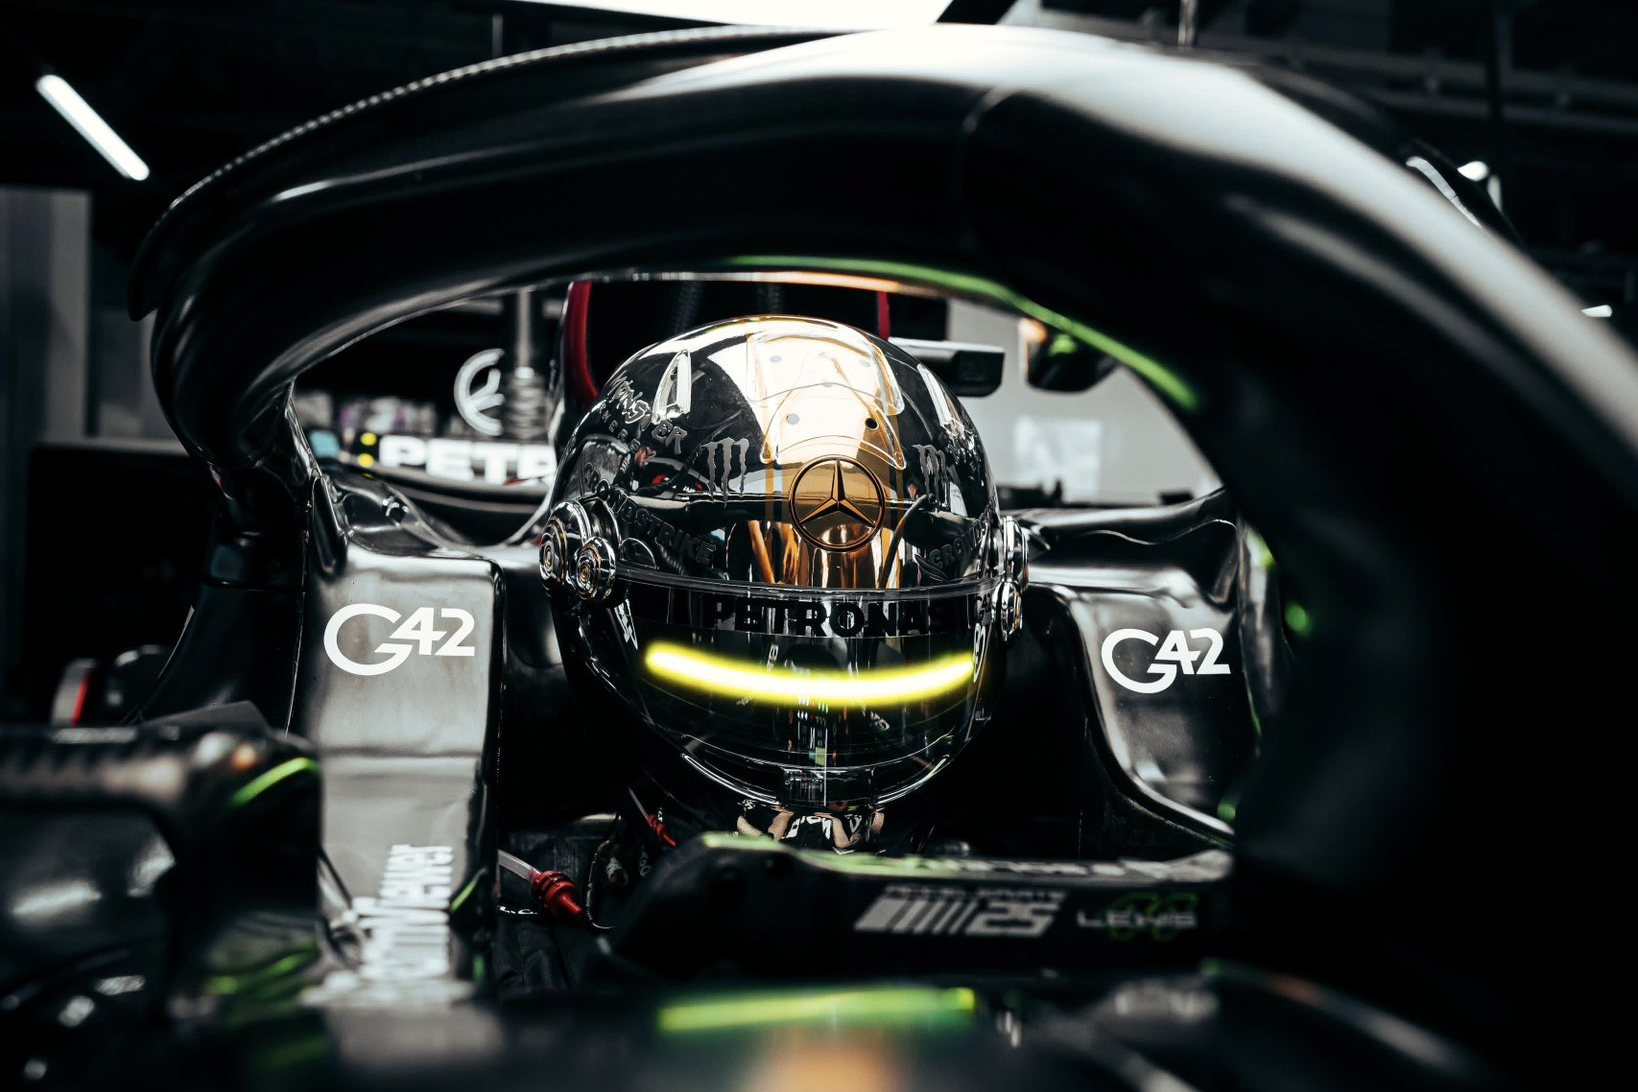

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

from pipeline import _parse_lap_time_to_ms

pd.set_option('display.max_rows', 1000)

In [2]:
drivers = pd.read_csv('data/driversgit.csv')
laptimes = pd.read_csv('data/laptimesgit.csv')
qualifying = pd.read_csv('data/qualifyinggit.csv')
races = pd.read_csv('data/racesgit.csv')
sgppits = pd.read_csv('data/sgppitsgitfinal.csv')
results = pd.read_csv('data/resultsgit.csv')
weather = pd.read_csv('data/weatherdescriptiongit.csv')

In [3]:
print(drivers.head(5))

   driverId   driverRef number code  forename     surname         dob  \
0         1    hamilton     44  HAM     Lewis    Hamilton  1985-01-07   
1         2    heidfeld     \N  HEI      Nick    Heidfeld  1977-05-10   
2         3     rosberg      6  ROS      Nico     Rosberg  1985-06-27   
3         4      alonso     14  ALO  Fernando      Alonso  1981-07-29   
4         5  kovalainen     \N  KOV    Heikki  Kovalainen  1981-10-19   

  nationality                                             url  
0     British     http://en.wikipedia.org/wiki/Lewis_Hamilton  
1      German      http://en.wikipedia.org/wiki/Nick_Heidfeld  
2      German       http://en.wikipedia.org/wiki/Nico_Rosberg  
3     Spanish    http://en.wikipedia.org/wiki/Fernando_Alonso  
4     Finnish  http://en.wikipedia.org/wiki/Heikki_Kovalainen  


In [4]:
print(laptimes.head(5))

   raceId  driverId  lap  position      time  milliseconds
0     841        20    1         1  1:38.109         98109
1     841        20    2         1  1:33.006         93006
2     841        20    3         1  1:32.713         92713
3     841        20    4         1  1:32.803         92803
4     841        20    5         1  1:32.342         92342


In [5]:
print(qualifying.head(5))

   qualifyId  raceId  driverId  constructorId  number  position        q1  \
0          1      18         1              1      22         1  1:26.572   
1          2      18         9              2       4         2  1:26.103   
2          3      18         5              1      23         3  1:25.664   
3          4      18        13              6       2         4  1:25.994   
4          5      18         2              2       3         5  1:25.960   

         q2        q3  
0  1:25.187  1:26.714  
1  1:25.315  1:26.869  
2  1:25.452  1:27.079  
3  1:25.691  1:27.178  
4  1:25.518  1:27.236  


In [6]:
print(races.head(5))

   raceId  year  round  circuitId                   name        date  \
0       1  2009      1          1  Australian Grand Prix  2009-03-29   
1       2  2009      2          2   Malaysian Grand Prix  2009-04-05   
2       3  2009      3         17     Chinese Grand Prix  2009-04-19   
3       4  2009      4          3     Bahrain Grand Prix  2009-04-26   
4       5  2009      5          4     Spanish Grand Prix  2009-05-10   

       time                                                url fp1_date  \
0  06:00:00  http://en.wikipedia.org/wiki/2009_Australian_G...       \N   
1  09:00:00  http://en.wikipedia.org/wiki/2009_Malaysian_Gr...       \N   
2  07:00:00  http://en.wikipedia.org/wiki/2009_Chinese_Gran...       \N   
3  12:00:00  http://en.wikipedia.org/wiki/2009_Bahrain_Gran...       \N   
4  12:00:00  http://en.wikipedia.org/wiki/2009_Spanish_Gran...       \N   

  fp1_time fp2_date fp2_time fp3_date fp3_time quali_date quali_time  \
0       \N       \N       \N       \N       

In [7]:
print(sgppits.head(5))

   Unnamed: 0  duration  stop  driverId  raceId
0           0    44.170     1       817    2011
1           1    29.549     1         3    2011
2           2    30.621     1         4    2011
3           3    29.610     1        30    2011
4           4    35.398     1       811    2011


In [8]:
print(results.head(5))

   resultId  raceId  driverId  constructorId number  grid position  \
0         1      18         1              1     22     1        1   
1         2      18         2              2      3     5        2   
2         3      18         3              3      7     7        3   
3         4      18         4              4      5    11        4   
4         5      18         5              1     23     3        5   

  positionText  positionOrder  points  laps         time milliseconds  \
0            1              1    10.0    58  1:34:50.616      5690616   
1            2              2     8.0    58       +5.478      5696094   
2            3              3     6.0    58       +8.163      5698779   
3            4              4     5.0    58      +17.181      5707797   
4            5              5     4.0    58      +18.014      5708630   

  fastestLap rank fastestLapTime fastestLapSpeed  statusId  
0         39    2       1:27.452         218.300         1  
1         41    3 

In [9]:
print(weather.head(5))

   Unnamed: 0  year                name  race_id     weather_description  \
0           0  1950   French Grand Prix      838           Hot and sunny   
1           1  1950  Belgian Grand Prix      837     Warm, dry and sunny   
2           2  1950  British Grand Prix      833       Sunny, mild, dry.   
3           3  1950    Indianapolis 500      835                   Rainy   
4           4  1950   Monaco Grand Prix      834  No weather description   

  is_it_wet  
0   Not Wet  
1   Not Wet  
2   Not Wet  
3       Wet  
4   Not Wet  


In [10]:
SINGAPORE_CIRCUIT_ID = 15
sgp_races = races.loc[races['circuitId'] == SINGAPORE_CIRCUIT_ID, ['raceId', 'year']]
sgp_ids = sgp_races['raceId']

# --- results: fastest lap time, finishing position, top-5 flag ------------
sgpresults = results.loc[results['raceId'].isin(sgp_ids)].copy()
sgpresults['fastestlaptime(ms)'] = sgpresults['fastestLapTime'].apply(_parse_lap_time_to_ms)
sgpresults['position'] = pd.to_numeric(sgpresults['position'], errors='coerce')  # DNF ('\N') -> NaN
sgpresults['position'] = sgpresults['position'].between(1, 5).astype(int)         # top 5 -> 1, else (incl. DNF) -> 0

# --- average lap time and grid position per driver, per race --------------
lap_avg = (
    laptimes.loc[laptimes['raceId'].isin(sgp_ids)]
    .groupby(['raceId', 'driverId'])['milliseconds']
    .mean()
    .reset_index(name='averagelaptime(ms)')
)
grid = (
    qualifying.loc[qualifying['raceId'].isin(sgp_ids), ['raceId', 'driverId', 'position']]
    .rename(columns={'position': 'grid'})
)

# --- average pit stop time per driver, per race ----------------------------
# NOTE: sgppitsgitfinal.csv's own "raceId" column actually holds the *year*
# of the race (e.g. 2011, 2012, ...), unlike every other table here which
# uses a real raceId -- so this one has to join on year instead.
pit_avg = (
    sgppits.loc[sgppits['raceId'].isin(sgp_races['year'])]
    .rename(columns={'raceId': 'year'})
    .groupby(['year', 'driverId'])['duration']
    .mean()
    .reset_index(name='averagepit(s)')
)

# --- race weather, keyed off weather.csv's own race_id --------------------
sgpweather = weather.loc[weather['race_id'].isin(sgp_ids), ['race_id', 'is_it_wet']].rename(
    columns={'race_id': 'raceId', 'is_it_wet': 'weather'}
)

# --- one row per driver per SGP edition, everything merged in -------------
merge_df3 = lap_avg.merge(grid, on=['raceId', 'driverId'], how='outer')
merge_df3 = merge_df3.merge(
    sgpresults[['raceId', 'driverId', 'fastestlaptime(ms)', 'position']],
    on=['raceId', 'driverId'], how='outer',
)
merge_df3 = merge_df3.merge(sgp_races, on='raceId', how='left')
merge_df3 = merge_df3.merge(pit_avg, on=['year', 'driverId'], how='outer')
merge_df3 = merge_df3.merge(sgpweather, on='raceId', how='left')
merge_df3 = merge_df3.merge(drivers[['driverId', 'code']], on='driverId', how='left')
merge_df3['driverId'] = merge_df3['code']  # keep working in driver codes, e.g. 'HAM', from here on
merge_df3 = merge_df3.drop(columns='code').sort_values('raceId').reset_index(drop=True)
# nullable Int64 (not float64) so downstream str(position) is '1'/'0', not '1.0'/'0.0'
merge_df3['position'] = merge_df3['position'].astype('Int64')
merge_df3['raceId'] = merge_df3['raceId'].astype('Int64')

# --- per-metric views used by the EDA plots below --------------------------
timedf = merge_df3[['raceId', 'driverId', 'averagelaptime(ms)', 'position']].dropna(subset=['averagelaptime(ms)']).reset_index(drop=True)
pitdf = merge_df3[['raceId', 'driverId', 'averagepit(s)', 'position']].dropna(subset=['averagepit(s)']).reset_index(drop=True)
griddf = merge_df3[['raceId', 'driverId', 'grid', 'position']].dropna(subset=['grid']).reset_index(drop=True)
fastestdf = merge_df3[['raceId', 'driverId', 'fastestlaptime(ms)', 'position']].dropna(subset=['fastestlaptime(ms)']).reset_index(drop=True)
weatherdf = merge_df3[['raceId', 'driverId', 'averagelaptime(ms)', 'weather']].dropna(subset=['weather']).reset_index(drop=True)

In [11]:
print(timedf.head(5))

   raceId driverId  averagelaptime(ms)  position
0      14      BUE       118276.489362         0
1      14      ROS       115182.196721         0
2      14      ALO       114474.770492         1
3      14      KOV       114794.983607         0
4      14      NAK       115121.163934         0


In [12]:
print(pitdf.head(5))

   raceId driverId  averagepit(s)  position
0      14      BUE      30.822667         0
1      14      ROS      21.180000         0
2      14      ALO      23.710000         1
3      14      KOV      24.005500         0
4      14      NAK      24.650000         0


In [13]:
griddf.head(5)

,raceId,driverId,grid,position
0,14,BUE,14.0,0
1,14,ROS,3.0,0
2,14,ALO,6.0,1
3,14,KOV,10.0,0
4,14,NAK,11.0,0


In [14]:
print(fastestdf.head(5))

   raceId driverId  fastestlaptime(ms)  position
0      14      BUE            110636.0         0
1      14      ROS            108352.0         0
2      14      ALO            108240.0         1
3      14      KOV            109283.0         0
4      14      NAK            109371.0         0


In [15]:
print(weatherdf.head(5))

   raceId driverId  averagelaptime(ms)  weather
0      14      BUE       118276.489362  Not Wet
1      14      ROS       115182.196721  Not Wet
2      14      ALO       114474.770492  Not Wet
3      14      KOV       114794.983607  Not Wet
4      14      NAK       115121.163934  Not Wet


In [16]:
# Merged Data Frame with all the values
print(merge_df3.head(5))

   raceId driverId  averagelaptime(ms)  grid  fastestlaptime(ms)  position  \
0      14      BUE       118276.489362  14.0            110636.0         0   
1      14      ROS       115182.196721   3.0            108352.0         0   
2      14      ALO       114474.770492   6.0            108240.0         1   
3      14      KOV       114794.983607  10.0            109283.0         0   
4      14      NAK       115121.163934  11.0            109371.0         0   

   year  averagepit(s)  weather  
0  2009      30.822667  Not Wet  
1  2009      21.180000  Not Wet  
2  2009      23.710000  Not Wet  
3  2009      24.005500  Not Wet  
4  2009      24.650000  Not Wet  


In [17]:
# --- season-form features: championship standings & experience, ----------
# --- computed from ALL circuits/years, not just Singapore -----------------

full_results = results.merge(races[['raceId', 'year', 'round']], on='raceId', how='left')
full_results['points'] = pd.to_numeric(full_results['points'], errors='coerce').fillna(0)
full_results = full_results.sort_values(['year', 'round'])

# cumulative championship points BEFORE each race (i.e. not counting that
# race's own points), within the season, per driver and per constructor
full_results['driver_points_before'] = (
    full_results.groupby(['year', 'driverId'])['points'].cumsum() - full_results['points']
)
full_results['constructor_points_before'] = (
    full_results.groupby(['year', 'constructorId'])['points'].cumsum() - full_results['points']
)

# championship standing (rank) at that same point in the season
full_results['driver_standing_before'] = (
    full_results.groupby(['year', 'raceId'])['driver_points_before'].rank(method='min', ascending=False)
)
full_results['constructor_standing_before'] = (
    full_results.groupby(['year', 'raceId'])['constructor_points_before'].rank(method='min', ascending=False)
)

# each driver's F1 debut year, from every circuit/season in the dataset
debut_year = full_results.groupby('driverId')['year'].min().rename('debut_year')
full_results = full_results.merge(debut_year, on='driverId', how='left')
full_results['years_experience'] = full_results['year'] - full_results['debut_year']
full_results['is_rookie'] = (full_results['years_experience'] == 0).astype(int)

season_form = full_results.loc[full_results['raceId'].isin(sgp_ids), [
    'raceId', 'driverId', 'driver_points_before', 'driver_standing_before',
    'constructor_points_before', 'constructor_standing_before',
    'years_experience', 'is_rookie',
]]
season_form = season_form.merge(drivers[['driverId', 'code']], on='driverId', how='left')
season_form = season_form.drop(columns='driverId').rename(columns={'code': 'driverId'})

merge_df3 = merge_df3.merge(season_form, on=['raceId', 'driverId'], how='left')
print(merge_df3.head(5))

   raceId driverId  averagelaptime(ms)  grid  fastestlaptime(ms)  position  \
0      14      BUE       118276.489362  14.0            110636.0         0   
1      14      ROS       115182.196721   3.0            108352.0         0   
2      14      ALO       114474.770492   6.0            108240.0         1   
3      14      KOV       114794.983607  10.0            109283.0         0   
4      14      NAK       115121.163934  11.0            109371.0         0   

   year  averagepit(s)  weather  driver_points_before  driver_standing_before  \
0  2009      30.822667  Not Wet                   3.0                    16.0   
1  2009      21.180000  Not Wet                  30.5                     6.0   
2  2009      23.710000  Not Wet                  20.0                     9.0   
3  2009      24.005500  Not Wet                  20.0                     9.0   
4  2009      24.650000  Not Wet                   0.0                    17.0   

   constructor_points_before  constructor_st

<span style="font-family: Courier New; font-size: 16px;">**Also added: a driver's own history at this circuit.** This mirrors what `pipeline.py`'s multi-circuit model calls `driver_circuit_avg_finish` -- a driver's average finishing position at Singapore specifically, from every prior edition they raced in (NaN on their first-ever Singapore GP). It's the Singapore-only version of the same feature; in the full multi-circuit model it's computed per-circuit instead of being implicitly "always Singapore."</span>

In [18]:
# --- driver's own historical average finish AT SINGAPORE, before this race ---
sgp_full_results = results.loc[results['raceId'].isin(sgp_ids)].merge(sgp_races, on='raceId', how='left')
sgp_full_results['position_num'] = pd.to_numeric(sgp_full_results['position'], errors='coerce')  # DNF -> NaN, excluded from the average
sgp_full_results = sgp_full_results.sort_values('year')
sgp_full_results['driver_circuit_avg_finish'] = (
    sgp_full_results.groupby('driverId')['position_num']
    .transform(lambda s: s.expanding().mean().shift(1))
)

circuit_history = sgp_full_results[['raceId', 'driverId', 'driver_circuit_avg_finish']]
circuit_history = circuit_history.merge(drivers[['driverId', 'code']], on='driverId', how='left')
circuit_history = circuit_history.drop(columns='driverId').rename(columns={'code': 'driverId'})

merge_df3 = merge_df3.merge(circuit_history, on=['raceId', 'driverId'], how='left')
merge_df3.head(5)

,raceId,driverId,averagelaptime(ms),grid,fastestlaptime(ms),position,year,averagepit(s),weather,driver_points_before,driver_standing_before,constructor_points_before,constructor_standing_before,years_experience,is_rookie,driver_circuit_avg_finish
0,14,BUE,118276.489362,14.0,110636.0,0,2009,30.822667,Not Wet,3.0,16.0,5.0,19.0,0.0,1.0,NaN
1,14,ROS,115182.196721,3.0,108352.0,0,2009,21.180000,Not Wet,30.5,6.0,30.5,11.0,3.0,0.0,2.0
2,14,ALO,114474.770492,6.0,108240.0,1,2009,23.710000,Not Wet,20.0,9.0,20.0,15.0,8.0,0.0,1.0
3,14,KOV,114794.983607,10.0,109283.0,0,2009,24.005500,Not Wet,20.0,9.0,57.0,7.0,2.0,0.0,10.0
4,14,NAK,115121.163934,11.0,109371.0,0,2009,24.650000,Not Wet,0.0,17.0,30.5,11.0,2.0,0.0,8.0


<span style="font-family: Courier New; font-size: 16px;">**Recency-weighted form.** `driver_standing_before` is season-cumulative, so a driver who started terribly but has been on fire the last few races looks the same as one who's been steady all year. These two features fix that: a driver's (and their team's) average finishing position over just their last 3 races, any circuit -- momentum, not a whole season blurred into one number. In testing (see `pipeline.py`), `driver_recent_form` and `constructor_recent_form` both ended up correlating with a top-5 finish *more strongly* than the season-long standing features.</span>

In [19]:
# --- recency-weighted form: last 3 races, any circuit, before this race ---
RECENT_FORM_WINDOW = 3

recent_full = results.merge(races[['raceId', 'year', 'round']], on='raceId', how='left')
recent_full['position_num'] = pd.to_numeric(recent_full['position'], errors='coerce')  # DNF -> NaN, excluded from the average
recent_full = recent_full.sort_values(['year', 'round'])

# driver: rolling average of their own last 3 results
recent_full['driver_recent_form'] = (
    recent_full.groupby('driverId')['position_num']
    .transform(lambda s: s.rolling(RECENT_FORM_WINDOW, min_periods=1).mean().shift(1))
)

# constructor: rolling average across BOTH cars' results, at the race level first
constructor_race_avg = (
    recent_full.groupby(['constructorId', 'raceId', 'year', 'round'])['position_num']
    .mean()
    .reset_index(name='constructor_race_avg_position')
    .sort_values(['year', 'round'])
)
constructor_race_avg['constructor_recent_form'] = (
    constructor_race_avg.groupby('constructorId')['constructor_race_avg_position']
    .transform(lambda s: s.rolling(RECENT_FORM_WINDOW, min_periods=1).mean().shift(1))
)
recent_full = recent_full.merge(
    constructor_race_avg[['constructorId', 'raceId', 'constructor_recent_form']],
    on=['constructorId', 'raceId'], how='left',
)

recent_form = recent_full[['raceId', 'driverId', 'driver_recent_form', 'constructor_recent_form']]
recent_form = recent_form.merge(drivers[['driverId', 'code']], on='driverId', how='left')
recent_form = recent_form.drop(columns='driverId').rename(columns={'code': 'driverId'})

merge_df3 = merge_df3.merge(recent_form, on=['raceId', 'driverId'], how='left')
merge_df3.head(5)

,raceId,driverId,averagelaptime(ms),grid,fastestlaptime(ms),position,year,averagepit(s),weather,driver_points_before,driver_standing_before,constructor_points_before,constructor_standing_before,years_experience,is_rookie,driver_circuit_avg_finish,driver_recent_form,constructor_recent_form
0,14,BUE,118276.489362,14.0,110636.0,0,2009,30.822667,Not Wet,3.0,16.0,5.0,19.0,0.0,1.0,NaN,12.500000,13.666667
1,14,ROS,115182.196721,3.0,108352.0,0,2009,21.180000,Not Wet,30.5,6.0,30.5,11.0,3.0,0.0,2.0,9.666667,11.666667
2,14,ALO,114474.770492,6.0,108240.0,1,2009,23.710000,Not Wet,20.0,9.0,20.0,15.0,8.0,0.0,1.0,5.500000,10.250000
3,14,KOV,114794.983607,10.0,109283.0,0,2009,24.005500,Not Wet,20.0,9.0,57.0,7.0,2.0,0.0,10.0,5.333333,6.000000
4,14,NAK,115121.163934,11.0,109371.0,0,2009,24.650000,Not Wet,0.0,17.0,30.5,11.0,2.0,0.0,8.0,13.666667,11.666667


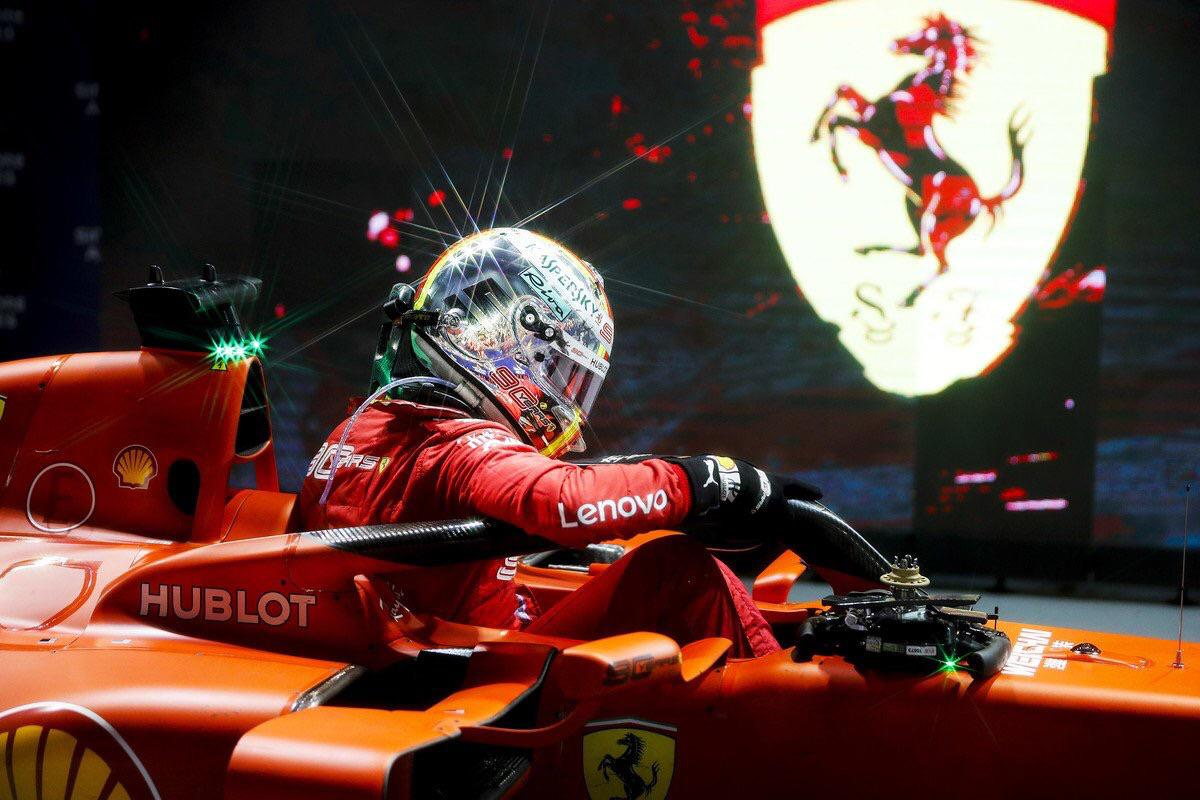

<Axes: >

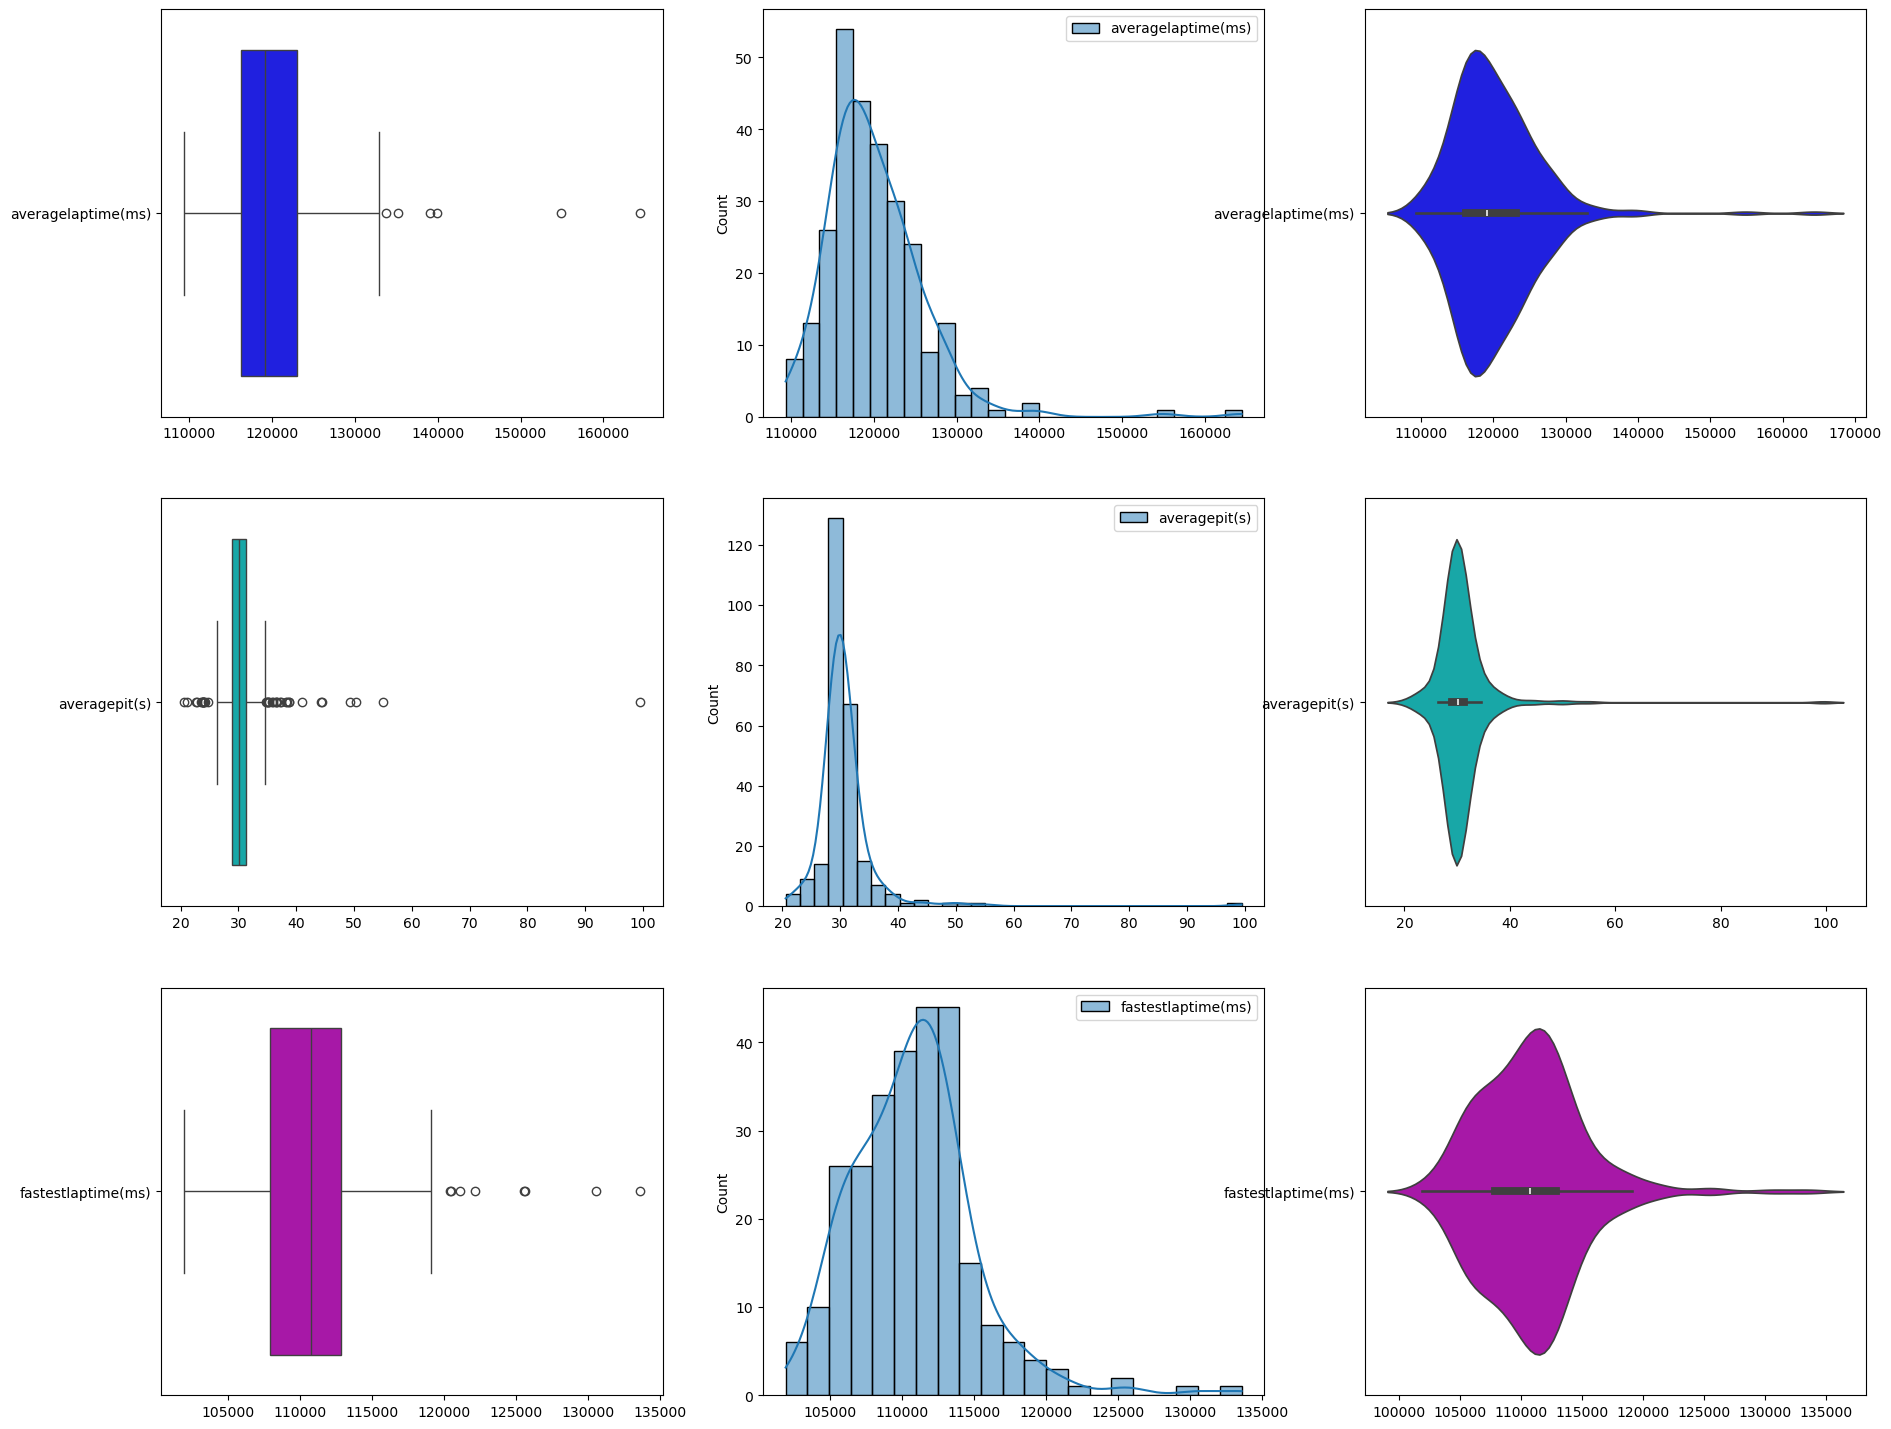

In [20]:
# uni-variate visualisation for timedf, pitdf and fastestdf

f, axes = plt.subplots(3, 3, figsize=(22,18))

# uni-variate visualisation for timedf eda

timedf_eda_uni = pd.DataFrame(timedf[["averagelaptime(ms)"]])
sb.boxplot(timedf_eda_uni, orient = "h", color = "b", ax = axes[0, 0]) # boxplot for averagelaptime
sb.histplot(timedf_eda_uni, kde = True, color = "b", ax = axes[0, 1]) # distplot for averagelaptime
sb.violinplot(timedf_eda_uni, orient = "h", color = "b", ax = axes[0, 2]) # violinplot for averagelaptime

# uni-variate visualisation for pitdf eda

pitdf_eda_uni = pd.DataFrame(pitdf[["averagepit(s)"]])
sb.boxplot(pitdf_eda_uni, orient = "h", color = "c", ax = axes[1, 0]) # boxplot for averagelaptime
sb.histplot(pitdf_eda_uni, kde = True, color = "c", ax = axes[1, 1]) # distplot for averagelaptime
sb.violinplot(pitdf_eda_uni, orient = "h", color = "c", ax = axes[1, 2]) # violinplot for averagelaptime

# uni-variate visualisation for fastestdf eda

fastestdf_eda_uni = pd.DataFrame(fastestdf[["fastestlaptime(ms)"]])
sb.boxplot(fastestdf_eda_uni, orient = "h", color = "m", ax = axes[2, 0]) # boxplot for averagelaptime
sb.histplot(fastestdf_eda_uni, kde = True, color = "m", ax = axes[2, 1]) # distplot for averagelaptime
sb.violinplot(fastestdf_eda_uni, orient = "h", color = "m", ax = axes[2, 2]) # violinplot for averagelaptime

Number of Grid Positions:  24
grid
1.0     13
2.0     13
3.0     13
4.0     13
5.0     13
6.0     13
7.0     13
8.0     13
9.0     13
10.0    13
11.0    13
12.0    13
13.0    13
14.0    13
15.0    13
16.0    13
17.0    13
18.0    13
19.0    13
20.0    13
21.0     6
22.0     6
23.0     3
24.0     3
Name: count, dtype: int64


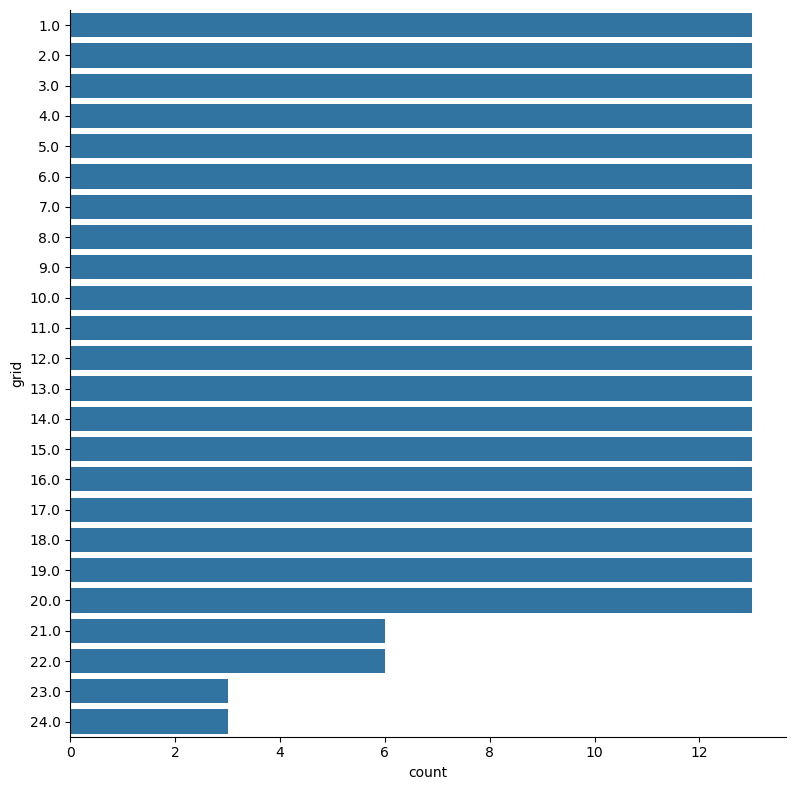

In [21]:
# uni-variate visualisation for griddf eda

griddf_eda_uni = pd.DataFrame(griddf[["grid"]])

# number of categories in the dataframe

print("Number of Grid Positions: ", len(griddf_eda_uni["grid"].unique()))

# frequencies of each category

print(griddf_eda_uni.value_counts().sort_index())
sb.catplot(y = "grid", data = griddf_eda_uni, kind = "count", height = 8) # 2010, 2011, 2012 has 24 drivers. 2013, 2014, 2016 has 22 drivers.

<Axes: xlabel='weather', ylabel='count'>

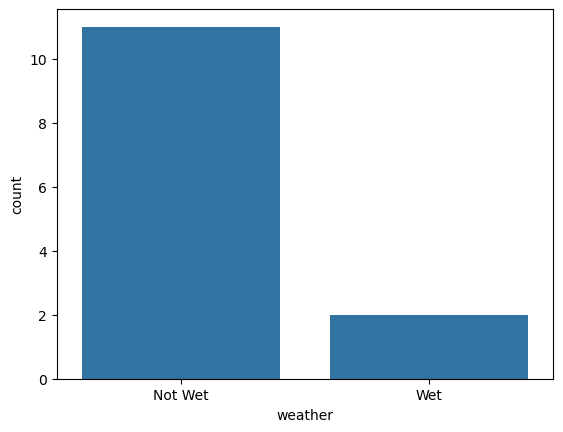

In [22]:
# uni-variate visualisation for weatherdf eda

sb.countplot(sgpweather, x="weather")

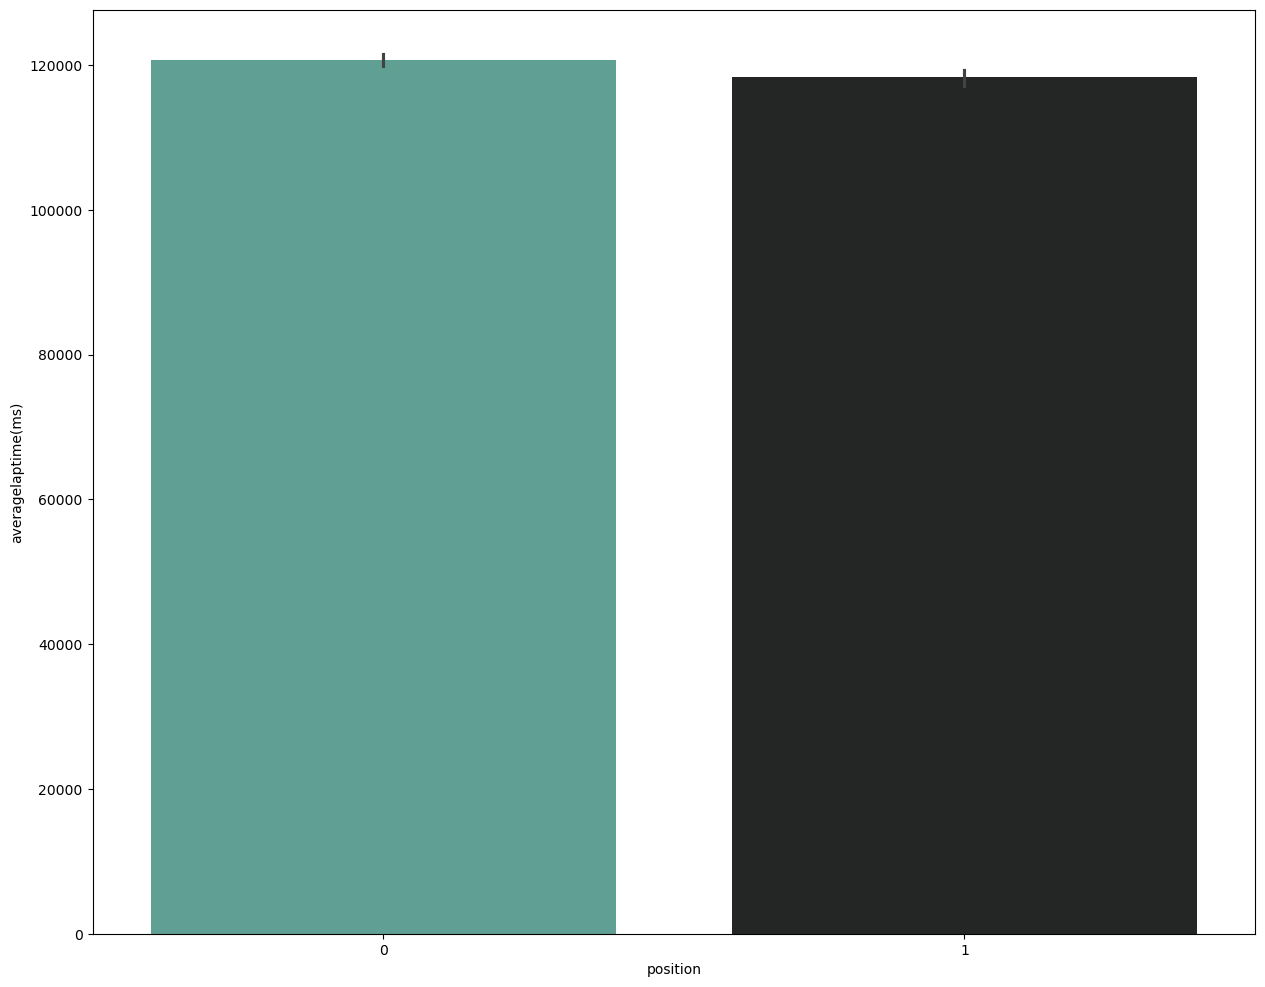

In [23]:
# barplot for timedf, averagelaptime(ms) vs position

plt.figure(figsize=(15, 12))
timedf_eda_uni2 = pd.DataFrame(timedf[["averagelaptime(ms)", "position"]])
sb.barplot(x = 'position', y = 'averagelaptime(ms)', data = timedf_eda_uni2, palette="dark:#5A9_r")
plt.show()

<Figure size 1000x1000 with 0 Axes>

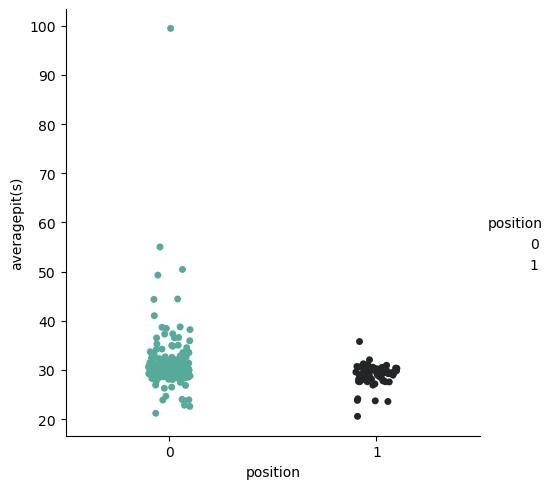

In [24]:
# catplot for pitdf, averagepit(s) vs position

f = plt.figure(figsize=(10, 10))
sb.catplot(data = pitdf, x = "position", y= "averagepit(s)", palette="dark:#5A9_r")

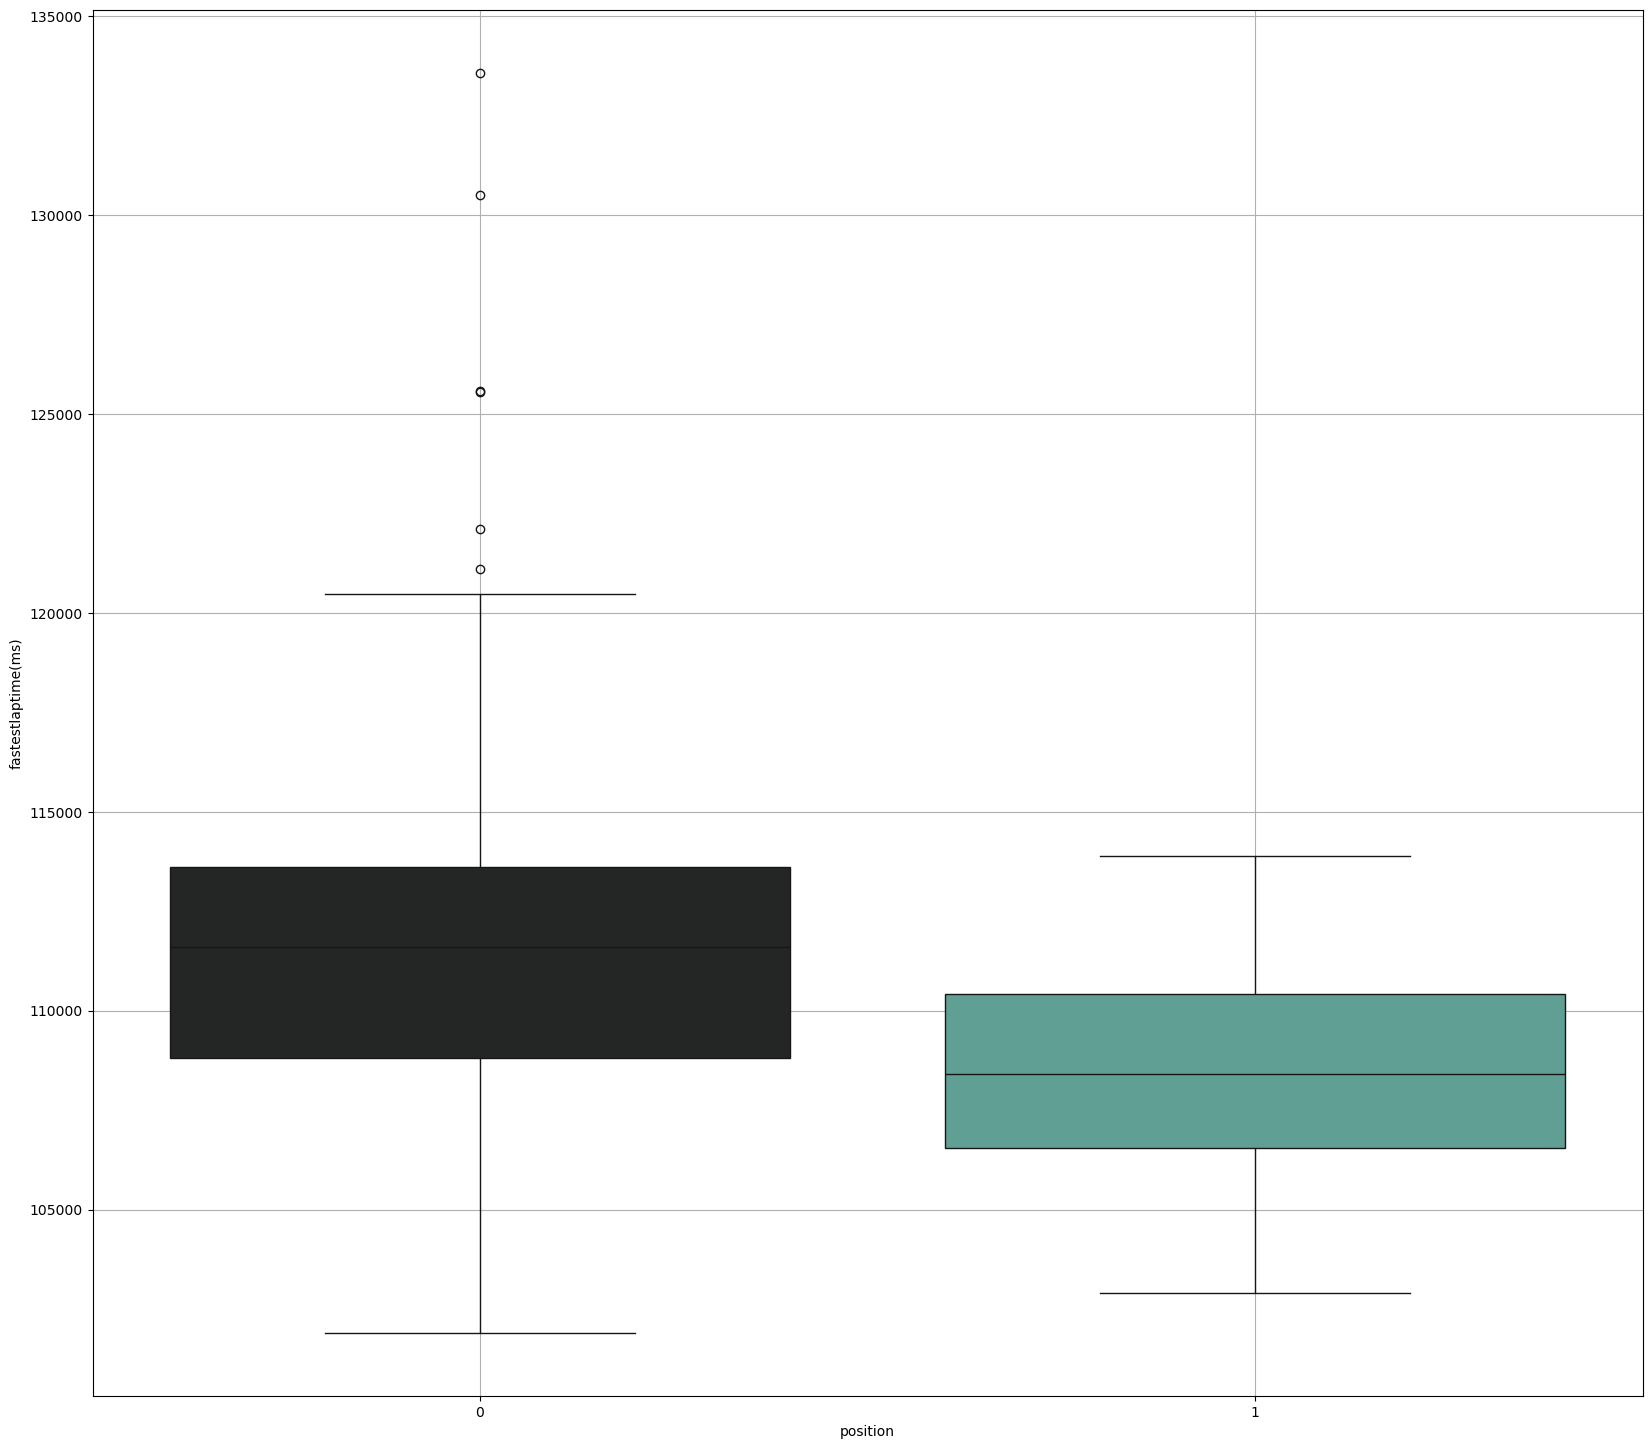

In [25]:
# boxplot for fastestdf, fastestlaptime(ms) vs Position

plt.figure(figsize=(20, 18))
timedf_eda_uni2 = sb.boxplot(y=fastestdf["fastestlaptime(ms)"], x=fastestdf["position"], width=0.8, palette="dark:#5A9")
plt.grid(True)
plt.show()

<Axes: xlabel='grid', ylabel='position'>

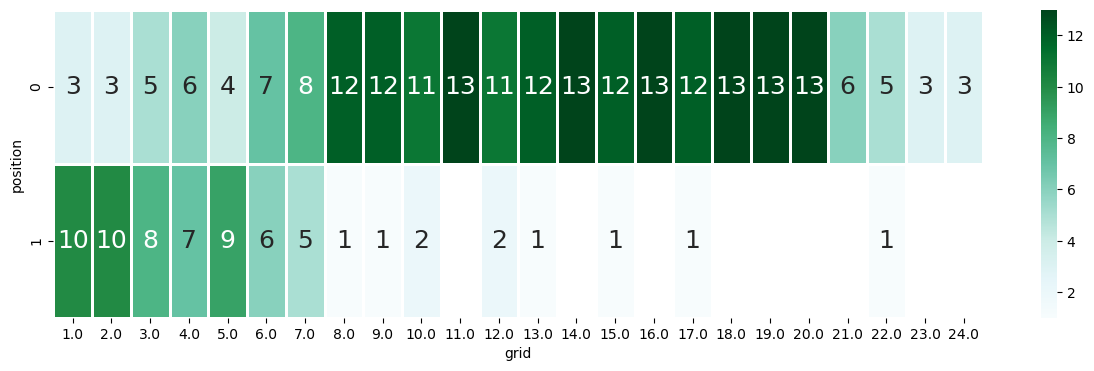

In [26]:
# heatmap for griddf, grid against position eda

f = plt.figure(figsize=(15, 4))
sb.heatmap(griddf.groupby(['position', 'grid']).size().unstack(), 
           linewidths = 1, annot = True, fmt = 'g', annot_kws = {"size": 18}, cmap = "BuGn")

<span style="font-family: Courier New; font-size: 16px;">**Why grid position isn't in the final model, despite the chart above:** it's a genuinely strong feature (correlation -0.57 with a top-5 finish, second only to `driver_standing_before`) -- but it doesn't exist until qualifying finishes, usually about a day before the race. A model that needs it can only ever be used the day before a race. `pipeline.py`'s model is built to work as soon as the *previous* race ends, using only standing/experience -- so grid position is explored here for completeness, but deliberately left out of the actual feature set. That trade-off costs real accuracy (~87% -> ~83% in testing) in exchange for having useful lead time instead of none.</span>

In [27]:
# Creating mergedf dataset without the values we do not wish to see in the EDA

mergedf = pd.DataFrame(merge_df3[['averagepit(s)', 'averagelaptime(ms)', 'fastestlaptime(ms)', 'grid', 'position']])

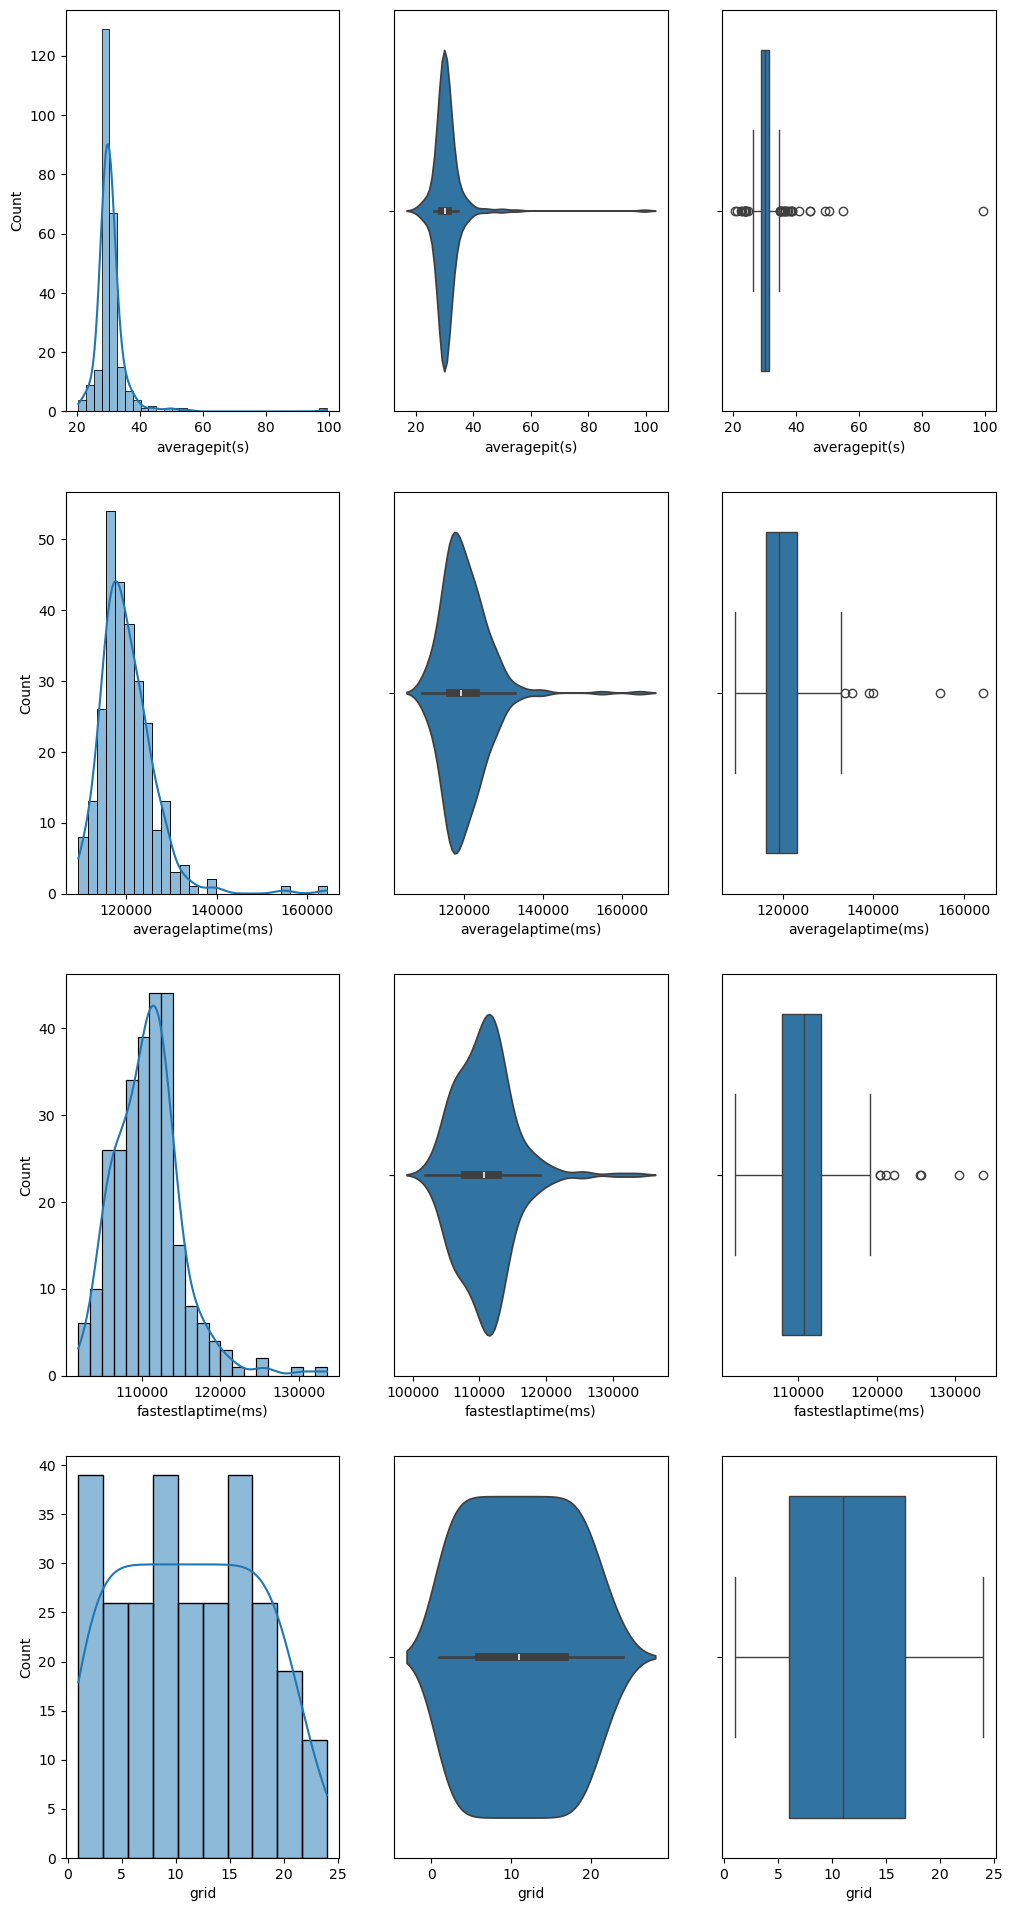

In [28]:
# distplot, violinplot, boxplot for mergedf

f, axes = plt.subplots(4, 3, figsize=(12,24))

count = 0 
for var in mergedf:
    if (count != 4):
        sb.histplot(mergedf[var], ax = axes[count,0], kde=True) 
        sb.violinplot(mergedf[var], ax = axes[count,1], orient = "h") 
        sb.boxplot(mergedf[var], ax = axes[count,2], orient = "h") 
        count += 1

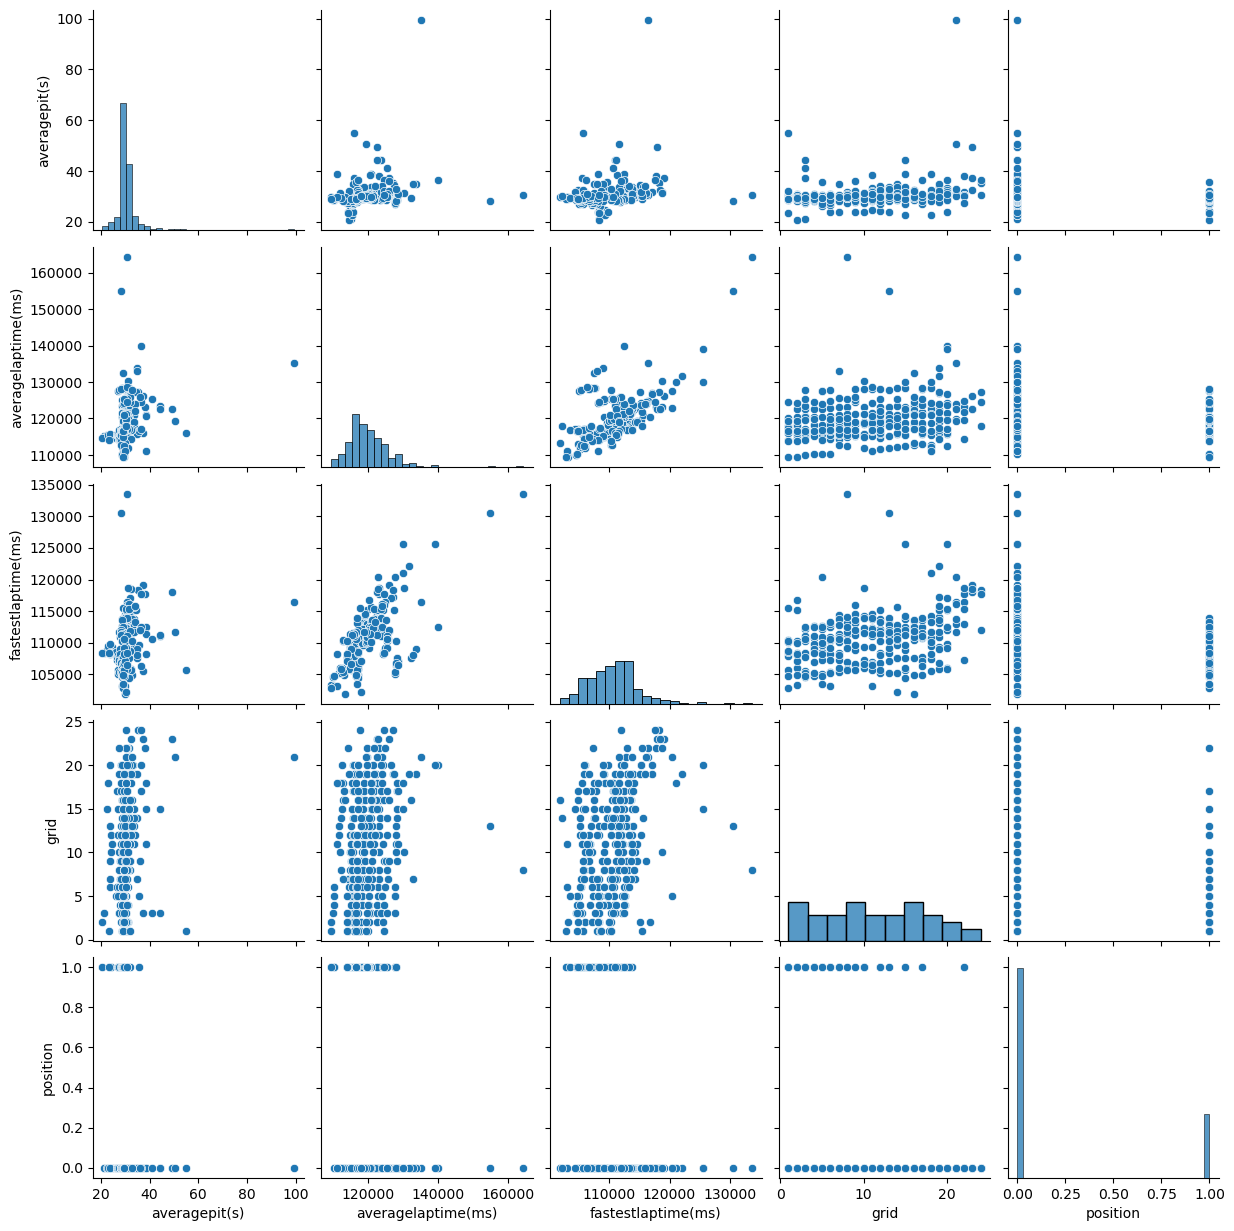

In [29]:
# pairplot for mergedf

sb.pairplot(data = mergedf)

<Axes: >

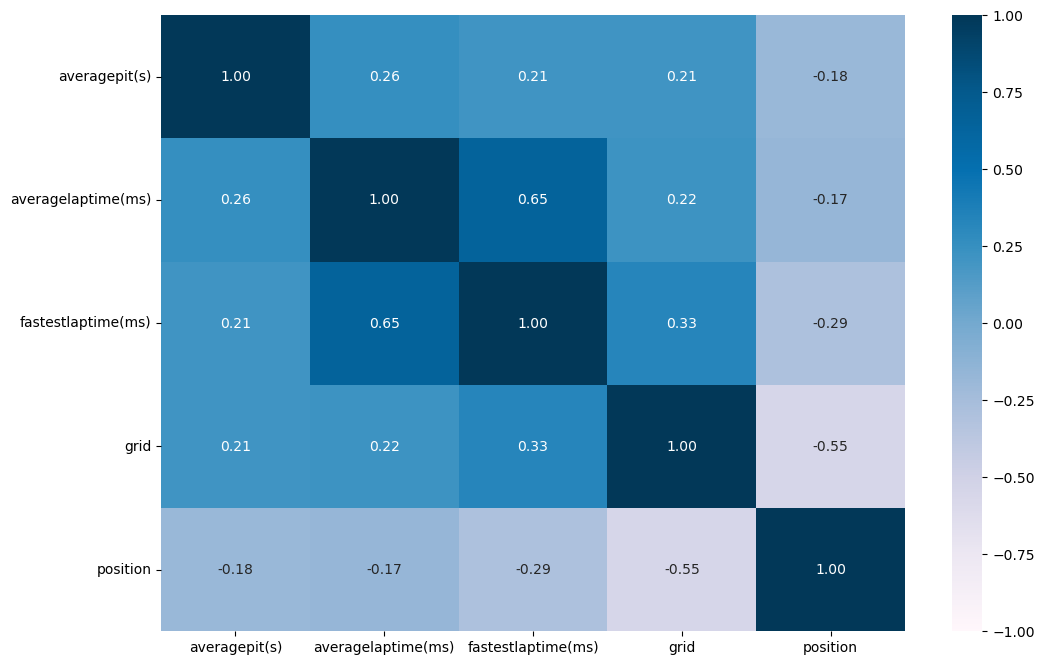

In [30]:
# heatmap for mergedf

f, axes = plt.subplots(1, 1, figsize=(12, 8))
sb.heatmap(mergedf.corr(), vmin = -1, vmax = 1, annot = True, fmt =".2f", cmap = "PuBu") # heatmap allowed us to differentiate the variables that we may have otherwised missed out in the corr matrix

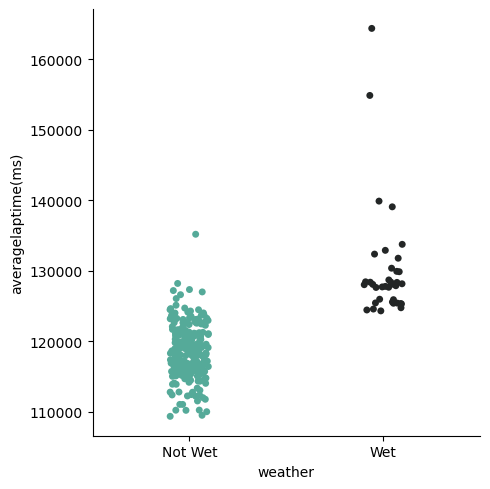

In [31]:
# catplot for weatherdf, weather against averagelaptime(ms)

sb.catplot(data = weatherdf, x = "weather", y= "averagelaptime(ms)", palette="dark:#5A9_r")

<Axes: xlabel='position', ylabel='count'>

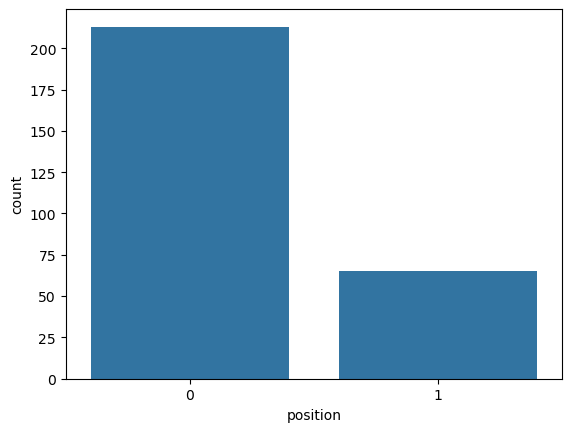

In [32]:
# imbalance in positions 0 and 1

sb.countplot(sgpresults, x="position")

<span style="font-family: Courier New; font-size: 16px;">**Why standing, not raw points, below:** `driver_points_before`/`constructor_points_before` aren't directly comparable across seasons -- F1's points system changed several times over 2008-2022 (a win was worth 10 points pre-2010, 25 after, plus later sprint-race points), so raw points mix "how competitive is this driver" with "which scoring era is this row from." The standing (rank) versions don't have that problem -- 1st place means the same thing in any season -- so those are what's plotted and used below.</span>

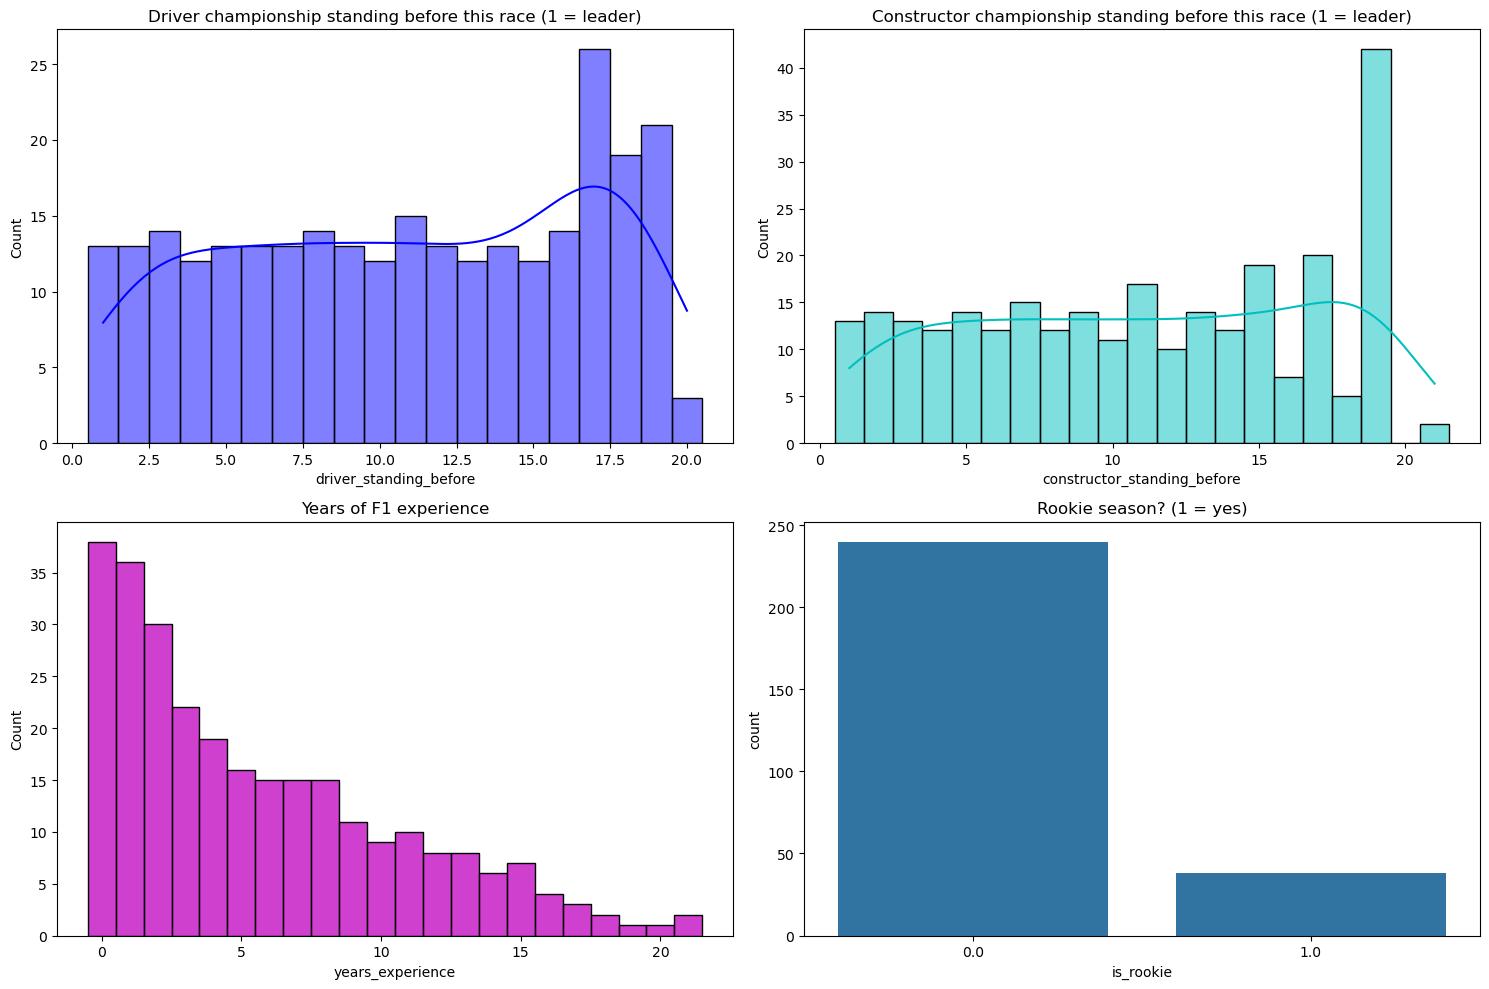

In [33]:
# uni-variate visualisation for the new season-form features
f, axes = plt.subplots(2, 2, figsize=(15, 10))

sb.histplot(merge_df3['driver_standing_before'], kde=True, discrete=True, ax=axes[0, 0], color='b')
axes[0, 0].set_title('Driver championship standing before this race (1 = leader)')

sb.histplot(merge_df3['constructor_standing_before'], kde=True, discrete=True, ax=axes[0, 1], color='c')
axes[0, 1].set_title('Constructor championship standing before this race (1 = leader)')

sb.histplot(merge_df3['years_experience'], kde=False, discrete=True, ax=axes[1, 0], color='m')
axes[1, 0].set_title('Years of F1 experience')

sb.countplot(x=merge_df3['is_rookie'], ax=axes[1, 1])
axes[1, 1].set_title('Rookie season? (1 = yes)')
plt.tight_layout()

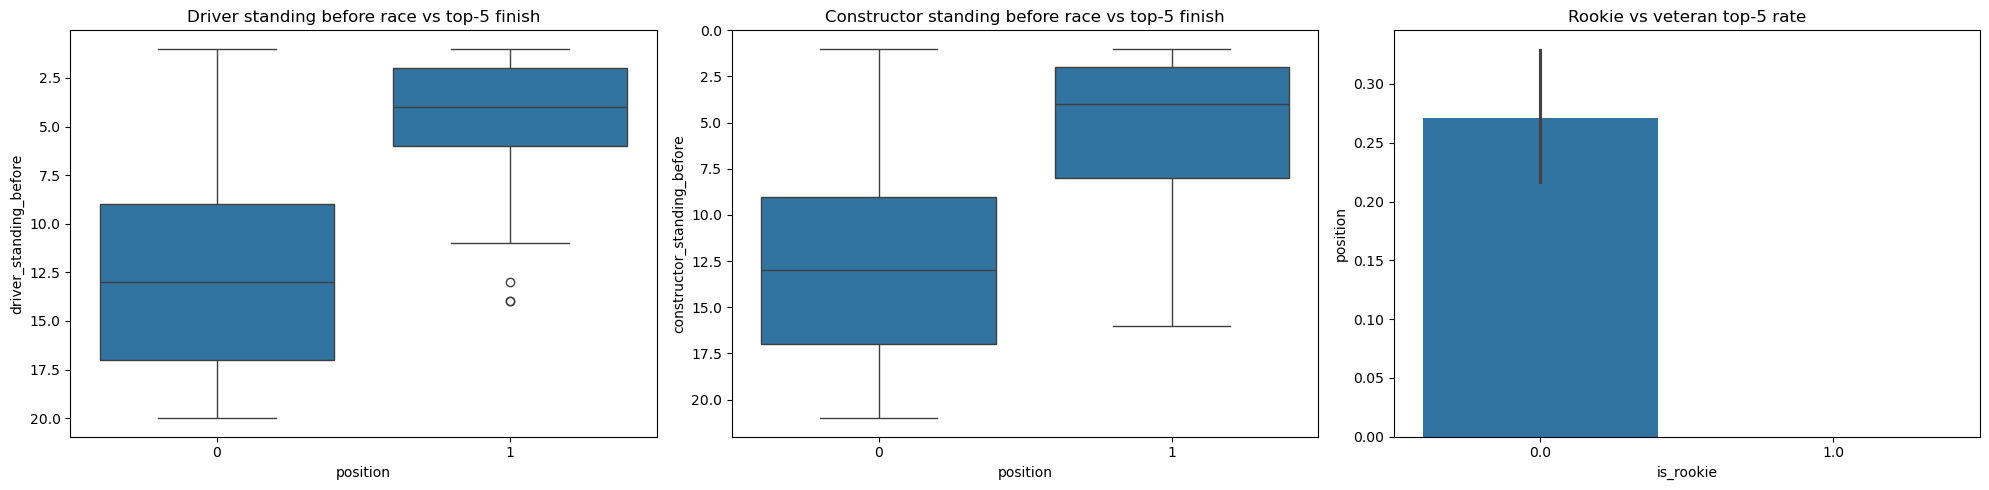

In [34]:
# bivariate: season-form features vs top-5 finish
f, axes = plt.subplots(1, 3, figsize=(20, 5))

sb.boxplot(x='position', y='driver_standing_before', data=merge_df3, ax=axes[0])
axes[0].set_title('Driver standing before race vs top-5 finish')
axes[0].invert_yaxis()  # rank 1 (best) at the top of the axis

sb.boxplot(x='position', y='constructor_standing_before', data=merge_df3, ax=axes[1])
axes[1].set_title('Constructor standing before race vs top-5 finish')
axes[1].invert_yaxis()

sb.barplot(x='is_rookie', y='position', data=merge_df3, ax=axes[2])
axes[2].set_title('Rookie vs veteran top-5 rate')
plt.tight_layout()

<span style="font-family: Courier New; font-size: 16px;">**What the chart above actually shows:** the boxes barely overlap for standing -- drivers who finish top 5 have a much better (lower) championship standing coming in than drivers who don't. The print-out below puts numbers on that, plus checks two things a plot alone won't tell you: how strong each relationship really is, whether driver standing and constructor standing might just be measuring the same thing (a fast car *is* how a driver gets a good standing), and how small the rookie sample actually is.</span>

In [35]:
# put numbers on the chart above, and check for things a boxplot won't show
print("Median standing, top-5 finishers vs not:")
print(merge_df3.groupby('position')[['driver_standing_before', 'constructor_standing_before']].median())
print()

print("Top-5 rate, rookies vs veterans:")
print(merge_df3.groupby('is_rookie')['position'].mean())
print(f"(sample sizes: {(merge_df3['is_rookie'] == 0).sum()} veteran rows, "
      f"{(merge_df3['is_rookie'] == 1).sum()} rookie rows -- rookies are a small slice, treat that number cautiously)")
print()

season_form_cols = ['driver_standing_before', 'constructor_standing_before',
                     'years_experience', 'is_rookie', 'position']
print("Correlation with top-5 finish:")
print(merge_df3[season_form_cols].corr()['position'].sort_values())
print()

print(f"driver_standing_before vs constructor_standing_before correlation: "
      f"{merge_df3['driver_standing_before'].corr(merge_df3['constructor_standing_before']):.2f}")
print("(high correlation here would mean these two features are largely capturing")
print(" the same underlying thing -- car competitiveness -- rather than two")
print(" independent signals)")

Median standing, top-5 finishers vs not:
          driver_standing_before  constructor_standing_before
position                                                     
0                           13.0                         13.0
1                            4.0                          4.0

Top-5 rate, rookies vs veterans:
is_rookie
0.0    0.270833
1.0         0.0
Name: position, dtype: Float64
(sample sizes: 240 veteran rows, 38 rookie rows -- rookies are a small slice, treat that number cautiously)

Correlation with top-5 finish:
driver_standing_before        -0.594971
constructor_standing_before   -0.529523
is_rookie                     -0.219813
years_experience               0.170199
position                       1.000000
Name: position, dtype: float64

driver_standing_before vs constructor_standing_before correlation: 0.92
(high correlation here would mean these two features are largely capturing
 the same underlying thing -- car competitiveness -- rather than two
 independent sig

Correlation with top-5 finish: -0.44
Rows with no prior Singapore history (first-timers): 84 / 279


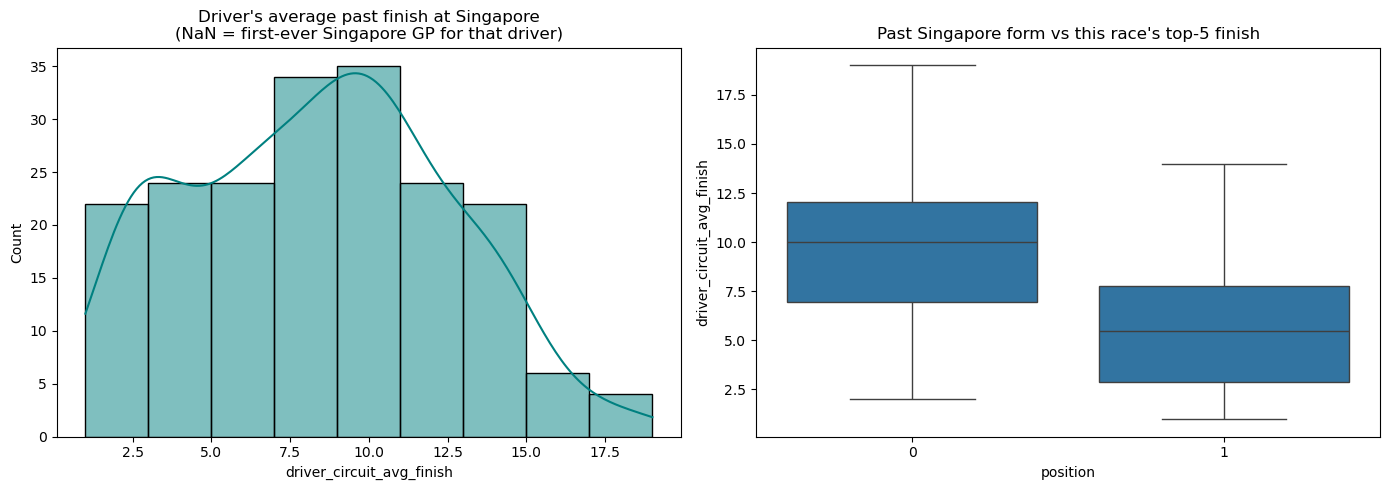

In [36]:
# uni-variate + bivariate: driver's own history at this circuit
f, axes = plt.subplots(1, 2, figsize=(14, 5))

sb.histplot(merge_df3['driver_circuit_avg_finish'], kde=True, ax=axes[0], color='teal')
axes[0].set_title("Driver's average past finish at Singapore\n(NaN = first-ever Singapore GP for that driver)")

sb.boxplot(x='position', y='driver_circuit_avg_finish', data=merge_df3, ax=axes[1])
axes[1].set_title('Past Singapore form vs this race\'s top-5 finish')
plt.tight_layout()

print(f"Correlation with top-5 finish: {merge_df3['driver_circuit_avg_finish'].corr(merge_df3['position']):.2f}")
print(f"Rows with no prior Singapore history (first-timers): "
      f"{merge_df3['driver_circuit_avg_finish'].isna().sum()} / {len(merge_df3)}")

Correlation with top-5 finish:
driver_recent_form        -0.522697
constructor_recent_form   -0.520525
driver_standing_before    -0.594971
position                   1.000000
Name: position, dtype: float64


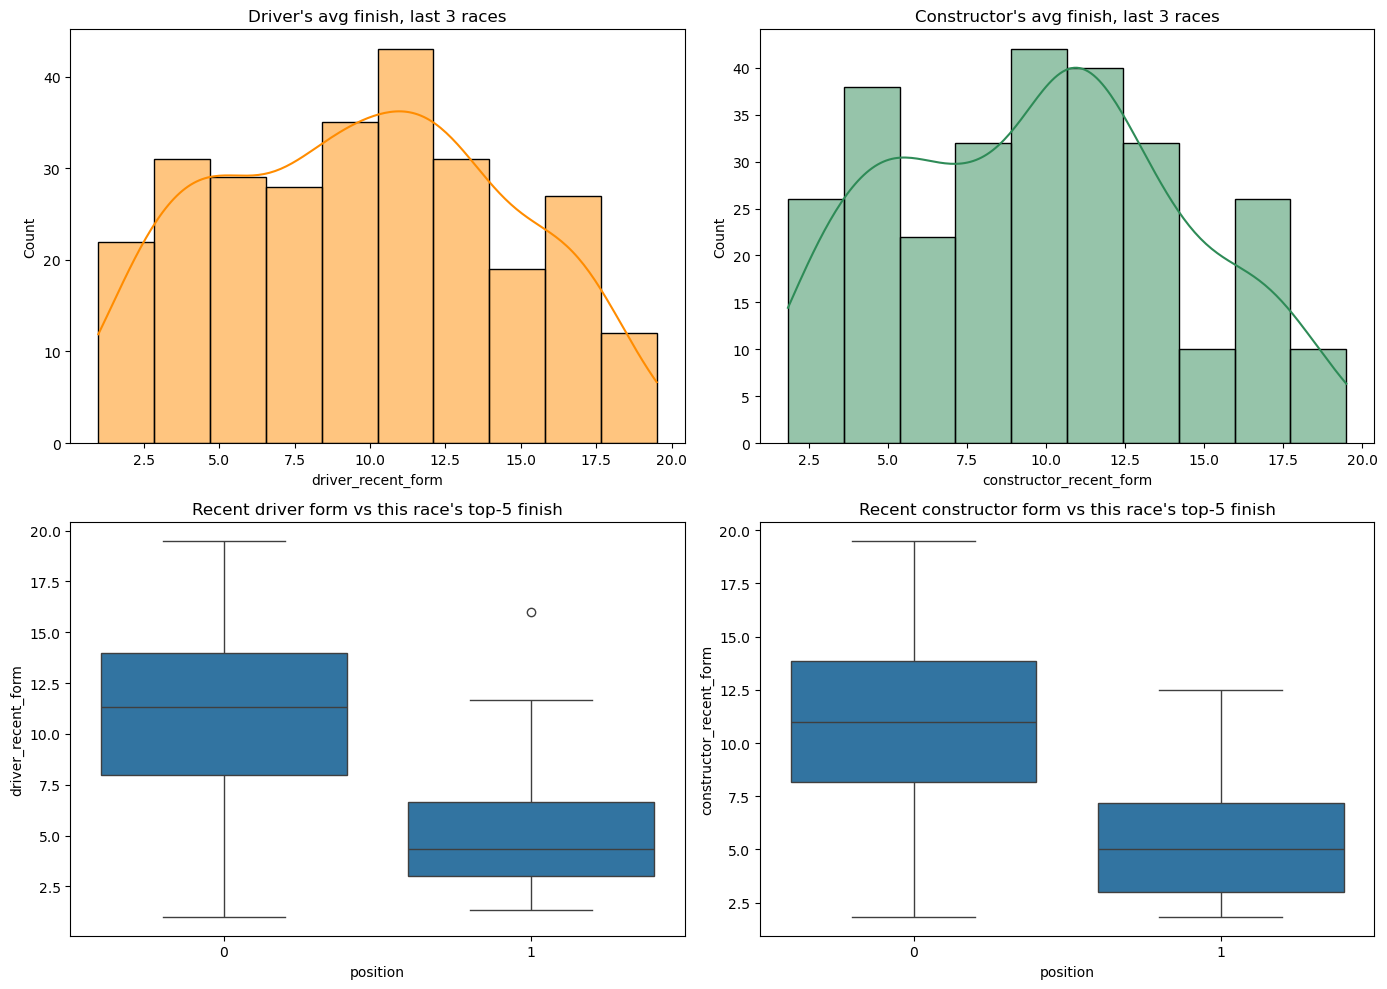

In [37]:
# uni-variate + bivariate: recency-weighted form
f, axes = plt.subplots(2, 2, figsize=(14, 10))

sb.histplot(merge_df3['driver_recent_form'], kde=True, ax=axes[0, 0], color='darkorange')
axes[0, 0].set_title("Driver's avg finish, last 3 races")

sb.histplot(merge_df3['constructor_recent_form'], kde=True, ax=axes[0, 1], color='seagreen')
axes[0, 1].set_title("Constructor's avg finish, last 3 races")

sb.boxplot(x='position', y='driver_recent_form', data=merge_df3, ax=axes[1, 0])
axes[1, 0].set_title('Recent driver form vs this race\'s top-5 finish')

sb.boxplot(x='position', y='constructor_recent_form', data=merge_df3, ax=axes[1, 1])
axes[1, 1].set_title('Recent constructor form vs this race\'s top-5 finish')
plt.tight_layout()

print("Correlation with top-5 finish:")
print(merge_df3[['driver_recent_form', 'constructor_recent_form',
                  'driver_standing_before', 'position']].corr()['position'])

In [ ]:
import analytics

# build_season_frame() reconstructs the feature frame straight from the CSVs
# (the web app hands compute() its already-cached one instead).
season_frame, season_year = analytics.build_season_frame("data")
report = analytics.compute(season_frame, season_year)

head = report["headline"]
print(f"Season analysed: {season_year}")
print(f"  races                {head['races']}")
print(f"  driver-race entries  {head['entries']}")
print(f"  drivers / teams      {head['drivers']} / {head['teams']}")
print(f"  rookies              {head['rookies']}")
print(f"  points finishes      {head['points_finishes']} of {head['classified']} classified"
      f"  ({head['points_rate']:.1%})")
print(f"  unclassified / DNF   {head['dnf_or_unclassified']}")
print()
print("Features:", ", ".join(analytics.FEATURES))
season_frame.head()

<span style="font-family: Courier New; font-size: 16px;">**Why the base rate is near 50%.** Ten of roughly twenty cars score every race, so a model that guessed "points" for everyone would already be right about half the time. That is the number every chart below has to be read against -- a feature is only worth anything if its groups pull *away* from that baseline.</span>

In [ ]:
# Which inputs separate a points finish from a non-score.
# Point-biserial correlation = Pearson with one binary side, so this is exact,
# not an approximation.
correlations = pd.DataFrame(report["correlations"])
correlations["direction"] = np.where(
    correlations["lower_is_better"], "lower is better", "higher is better")
display(correlations[["label", "correlation", "direction", "coverage"]])

f = plt.figure(figsize=(9, 4))
order = correlations.iloc[::-1]
colours = np.where(order["correlation"] < 0, "#e66767", "#3987e5")
plt.barh(order["label"], order["correlation"], color=colours)
plt.axvline(0, color="0.4", linewidth=1)
plt.xlabel("Correlation with a points finish")
plt.title(f"Feature vs points finish, {season_year}")
plt.tight_layout()

<span style="font-family: Courier New; font-size: 16px;">**Reading the signs.** Every position- and form-based feature is negative, and that is the *expected* direction: P1 is a smaller number than P10, so a lower value going with a points finish is the feature working. `years_experience` is the one input where higher is better, and it is also the weakest -- experience barely moves the outcome once the car is accounted for.</span>

In [ ]:
# Points-finish rate across each feature's range. A correlation is one number
# for a whole relationship; this shows the shape -- whether the feature climbs
# steadily or only separates at one end.
buckets = [entry for entry in report["rate_by_bucket"] if entry["labels"]]
f, axes = plt.subplots(2, 4, figsize=(20, 8))
base_rate = report["headline"]["points_rate"]

for ax, entry in zip(axes.flatten(), buckets):
    ax.bar(range(len(entry["labels"])), entry["rates"], color="#3987e5")
    ax.axhline(base_rate, color="0.5", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(entry["labels"])))
    ax.set_xticklabels(entry["labels"], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(entry["label"], fontsize=11)
    ax.set_ylabel("points-finish rate")

for ax in axes.flatten()[len(buckets):]:
    ax.axis("off")
f.suptitle(f"Points-finish rate by feature bucket, {season_year} "
           f"(dashed line = season base rate {base_rate:.1%})")
plt.tight_layout()

In [ ]:
# Distribution of each feature, plus how much of the season it is populated for.
distributions = [entry for entry in report["distributions"] if entry["counts"]]
f, axes = plt.subplots(2, 4, figsize=(20, 7))
missing = {row["feature"]: row for row in report["missingness"]}

for ax, entry in zip(axes.flatten(), distributions):
    ax.bar(range(len(entry["counts"])), entry["counts"], color="#3987e5")
    ax.set_xticks([0, len(entry["bins"]) - 1])
    ax.set_xticklabels([entry["bins"][0], entry["bins"][-1]], fontsize=8)
    gap = missing[entry["feature"]]["missing_pct"]
    ax.set_title(f"{entry['label']}" + (f"  ({gap:.0%} missing)" if gap else ""), fontsize=11)

for ax in axes.flatten()[len(distributions):]:
    ax.axis("off")
f.suptitle(f"Feature distributions, {season_year}")
plt.tight_layout()

display(pd.DataFrame(report["missingness"])[["label", "missing", "missing_pct"]])

<span style="font-family: Courier New; font-size: 16px;">**The gaps are real, not a bug.** `driver_circuit_avg_finish` is empty whenever a driver has never raced that circuit before, and `driver_recent_form` is empty for a driver's first races of a career. The model imputes those, which is fine -- but a chart of a feature that is a quarter missing deserves to be read knowing that.</span>

In [ ]:
# Who the rate actually belongs to. Constructors first, then drivers --
# the site draws exactly these two tables.
teams = pd.DataFrame(report["by_team"])
drivers_rate = pd.DataFrame(report["by_driver"])
print(f"Points-finish rate by constructor, {season_year}")
display(teams[["team", "rate", "scores", "entries"]])
print(f"Top 10 drivers by points finishes, {season_year}")
display(drivers_rate.head(10)[["driver", "rate", "scores", "entries"]])

<span style="font-family: Courier New; font-size: 16px;">**Why none of this leaks.** Every feature above is built from races *before* the one it describes -- expanding means and rolling windows are shifted by one race, and a driver's own contribution is subtracted out of any season total. So a row's features could all have been computed on the morning of that race, which is exactly the condition the deployed model has to work under when it predicts a race that has not been run.</span>